### This is a simple notebook to train a Support Vector Machine to discriminate between two types of collisional events.

It accompanies Chapter 4 of the book.  
Data for this exercise were kindly provided by [Sascha Caron](https://www.nikhef.nl/~scaron/).  
Copyright: Viviana Acquaviva (2023)  
License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)
Modified by Aaron Romanowsky.

In [433]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # New algorithm!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics
from sklearn.model_selection import GridSearchCV # New! This will be used to explore different hyperparameter choices.
import seaborn as sns
import sklearn

In [434]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

Textbook code includes (buggy) preface on how to get data file.

Read in features and labels.

In [435]:
features = pd.read_csv('ParticleID_features.csv', index_col='ID')

In [436]:
features.head()

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.19933,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.2,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.65386,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.3,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.68461,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.8,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.87132,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.1,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.87641,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [437]:
features.shape

(5000, 67)

In [438]:
y_original = np.genfromtxt('ParticleID_labels.txt', dtype = str)
y_original

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      shape=(5000,), dtype='<U5')

#### We need to turn categorical (string-type) labels into an array, e.g. 0/1.

In [439]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() #turns categorical into 1 ... N

In [440]:
y = le.fit_transform(y_original)
y

array([1, 1, 1, ..., 1, 0, 1], shape=(5000,))

Our transformer used 1 for the first instance, but we actually wanted 4top to be the positive label, so we'll flip the labels:

In [441]:
target = np.abs(y - 1)
target # Happier now.

array([0, 0, 0, ..., 0, 1, 0], shape=(5000,))

#### Let's take a look at these features, using the "describe" property.

In [442]:
features.describe() #Note that this automatically excludes non-numerical type columns

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24,P25,P26,P27,P28,P29,P30,P31,P32,P33,P34,P35,P36,P37,P38,P39,P40,P41,P42,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.000000,-1.226980,-1.513330,4.410735e+04,26589.250000,-1.223240,-1.422415,4.092160e+04,25298.300000,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279,9.206885e+04,41054.850000,0.054393,-0.079641,8.593460e+04,37378.30000,-0.046667,0.040528,7.975460e+04,34681.700000,0.025305,0.046141,8.315485e+04,33683.550000,0.156083,-0.015617,7.894980e+04,33328.000000,0.072709,-0.052590,7.609735e+04,30942.700000,0.035675,0.090282,7.568430e+04,29479.700000,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.9999

### Important:

Looking at the "count" row, we can see that the whole data set has 5,000 rows, but some columns are present only for a fraction of them. This is because of the variable number of products in each collision.

#### Option 1: Only consider first 16 columns (first four products) so we have limited imputing/manipulation problems.

We have a trade-off between keeping more features, but having a more severe missing data/imputing problem, or keeping fewer features, but dealing with a simpler imputing problem. We are choosing the latter.

In [443]:
features_lim = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16']]

In [444]:
features_lim.head()

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [445]:
features_lim.describe() #This automatically excludes non-numerical type columns, and missing values/NaNs are not counted.

,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


There are still some feature columns with different length (but a small fraction now).  
This means there might be NaN values. Let's replace them with 0 for the moment. 

In [446]:
features_lim = features_lim.fillna(0) #Fill with 0 everywhere there is a NaN

In [447]:
features_lim = features_lim.drop(['METphi','P3','P4','P5','P7','P8','P11','P12'], axis=1) #This is a circular variable, so it is not useful for our purposes. We will drop it.


Note: this is the simplest but worst possible choice - imputing a constant value skews the model :D One step up would be to input the mean or median for each column. However, because only a limited number of instances have missing data, the choice of imputing strategy doesn't matter too much.

#### Let's see what "describe" says now.

In [448]:
features_lim.describe()

,MET,P1,P2,P6,P9,P10,P13,P14,P15,P16
count,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,3.301357e+05,1.540486e+05,1.079653e+05,2.096800e+05,74114.709700,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,3.068202e+05,1.149469e+05,8.138121e+04,2.506651e+05,46675.655162,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,3.857940e+04,2.825400e+04,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,1.369522e+05,8.883690e+04,6.320943e+04,7.488228e+04,46165.375000,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,2.263525e+05,1.182015e+05,8.581595e+04,1.277135e+05,62167.100000,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,4.077158e+05,1.771265e+05,1.238520e+05,2.406498e+05,89065.300000,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.186360e+06,1.276710e+06,1.146330e+06,2.800410e+06,788338.000000,2.503590e+06,481884.000000,4.730480,3.139660


Yay - we now have consistent sizes, so we can use these as feature arrays, BUT be mindful of possible negative impacts of our imputing strategies.

In [449]:
LearningSet = features_lim.copy(deep=True)
LearningSet['label'] = y_original

### Visualize the data!

<Figure size 640x480 with 0 Axes>

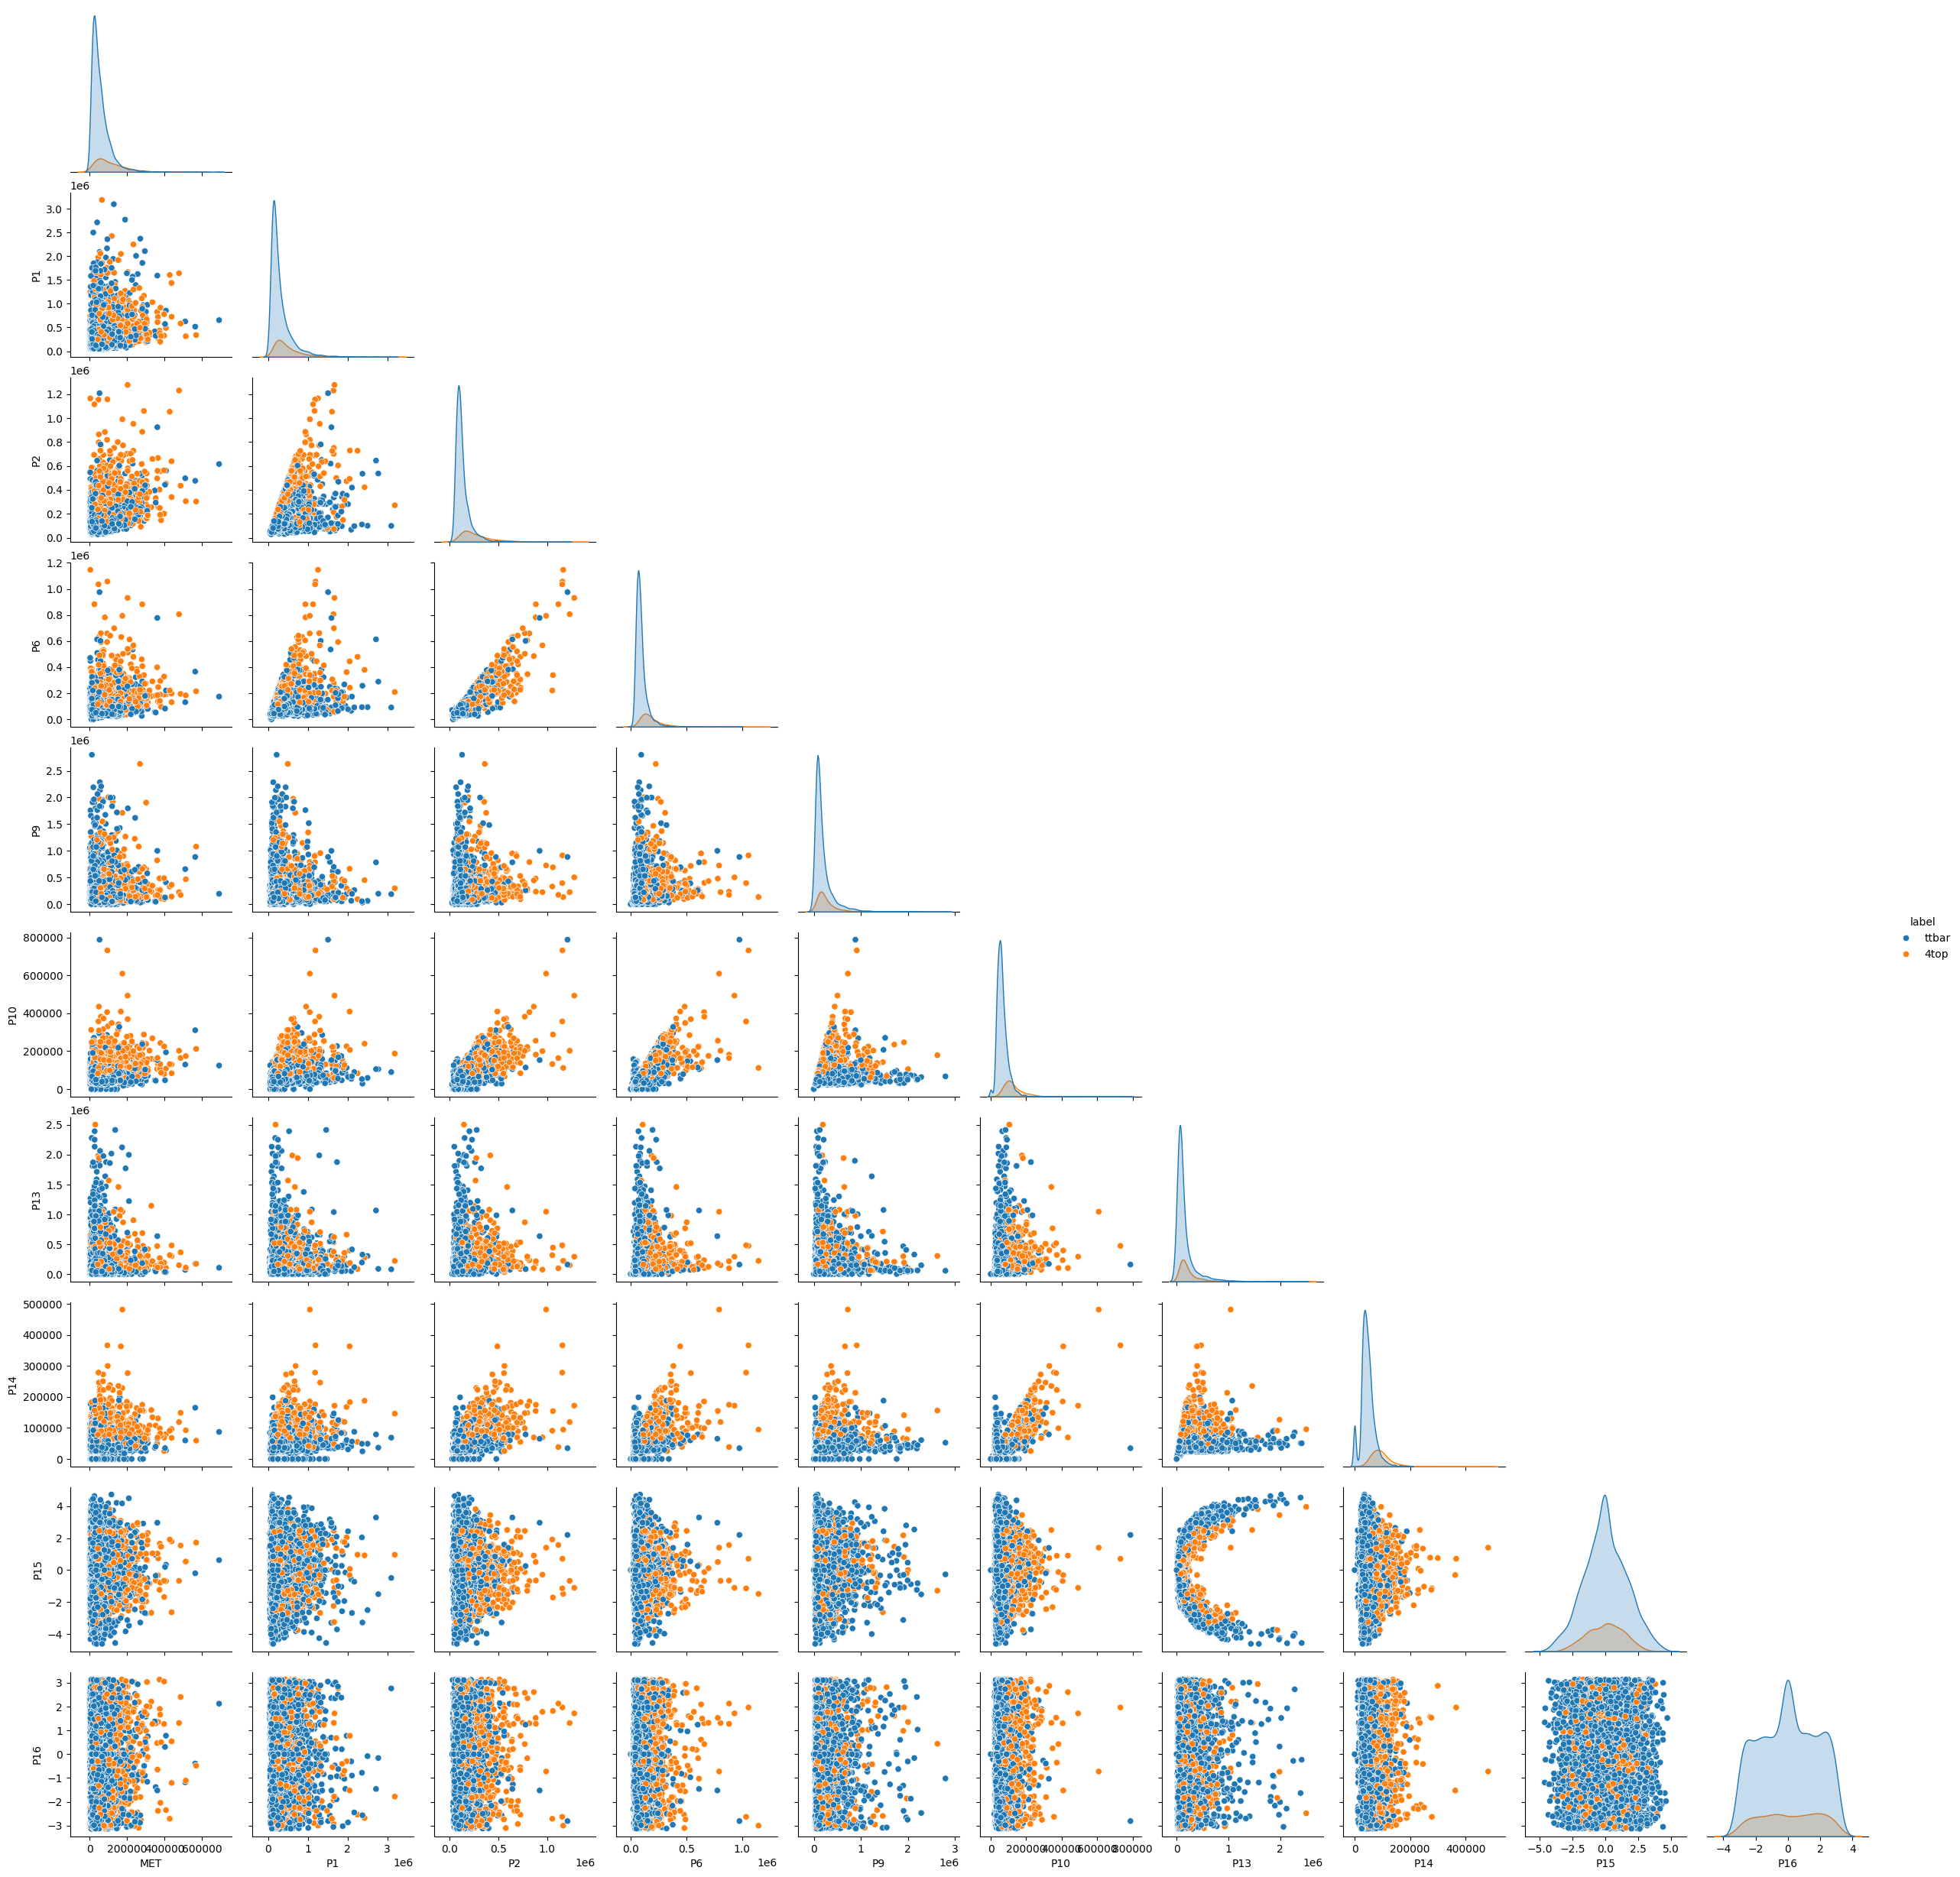

In [450]:
fig1 = plt.figure()
p = sns.pairplot(LearningSet,corner=True,hue='label')
#p=sns.pairplot(LearningSet2,vars=['S_MASS','log_distance','log_period'],corner=True,hue='P_HABITABLE',plot_kws={"s":100,"alpha":0.7})

### Let's move onto a quick exploration of labels and benchmarking.

In [451]:
np.sum(target)/len(target) #distribution 

np.float64(0.1622)

84\% in the negative label, 16\% in the positive label. 

This means that a classifier that puts everything in the negative class will have 84\% accuracy.

<span style="color: red">How about a random classifier that just assigns a random value according to class distribution?</span>

In [452]:
#Numerical solution

acc=0
for i in range(1000):
    x = np.random.choice(target,5000)
    acc += metrics.accuracy_score(target,x)
print(acc/1000)

#Analytic solution : use confusion matrix to visualize

print(0.8378*(0.8378) + 0.1622*0.1622)

0.7280197999999998
0.72821768


In conclusion, a "random" classifier would have 73% accuracy; a dummy classifier that predicts the most frequent class would have 83% accuracy. These are useful in order to set the expectation for what "a good result" is and what constitutes a significant improvement.

### Let's start with a linear model; model = SVC()

Define a cross-validation strategy; establish benchmark for a (very simple) linear model.

In [453]:
bmodel = LinearSVC(dual = False) #Prefer dual=False when n_samples > n_features. If not, will not converge!!

In [454]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101) 

In [455]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [456]:
l_benchmark_lim

{'fit_time': array([0.00401425, 0.00408292, 0.00388527, 0.00371337, 0.00370598]),
 'score_time': array([0.00074673, 0.00088596, 0.00072885, 0.00124288, 0.0006907 ]),
 'test_score': array([0.836, 0.829, 0.834, 0.828, 0.83 ]),
 'train_score': array([0.83525, 0.83475, 0.8305 , 0.83325, 0.83225])}

In [457]:
#np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3)
print('test accuracy = %.3f +/- %.3f' % (l_benchmark_lim['test_score'].mean(), l_benchmark_lim['test_score'].std()))

test accuracy = 0.831 +/- 0.003


This may look like a good number, but we know that it's not that impressive, as it merely matches a "dummy" classifier.

We can also check the predicted labels. Cross\_val\_predict will compile labels predicted when each object was in the test fold.

In [458]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)
print(ypred_bench_lim)
print(sum(ypred_bench_lim))

[0 0 0 ... 0 0 0]
48


### Question: is there perhaps something that we should have done before building the SVM model?

### How about scaling?

Implementation notes: Technically, standardizing/normalizing data using the entire learning set introduces leakage between train and test set (the test set "knows" about the mean and standard deviation of the entire data set). Usually this is not a dramatic effect, but the correct procedure is to derive the scaler within each CV fold (i.e. after separating in train and test), only on the train set, and apply the same transformation to the test set. The model then becomes a pipeline.

In [459]:
from sklearn.pipeline import make_pipeline #This allows one to build different steps together

In [460]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000)) #changed to linear SVC
# why C = 1000 ?
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [461]:
benchmark_lim_piped

{'fit_time': array([0.00426102, 0.00352597, 0.00335789, 0.00355792, 0.00343895]),
 'score_time': array([0.0009315 , 0.00085807, 0.00090361, 0.00082088, 0.00080442]),
 'test_score': array([0.894, 0.891, 0.888, 0.891, 0.894]),
 'train_score': array([0.893  , 0.89275, 0.89375, 0.89475, 0.8905 ])}

In [462]:
#np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3)
print('test accuracy = %.3f +/- %.3f' % (benchmark_lim_piped['test_score'].mean(),benchmark_lim_piped['test_score'].std()))

test accuracy = 0.892 +/- 0.002


In [463]:
#np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3)
print('train accuracy = %.3f +/- %.3f' % (benchmark_lim_piped['train_score'].mean(),benchmark_lim_piped['train_score'].std()))

train accuracy = 0.893 +/- 0.001


This is a significant improvement (woo-ooh!), and the comparison between test and train scores tells us already something about the problem that we have. We can formalize this by looking at the learning curves, which tell us both about gap between train/test scores, AND whether we need more data.

### Learning curves 

In [464]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)
 
    plt.ylabel("Accuracy score",fontsize = 14)
    
    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

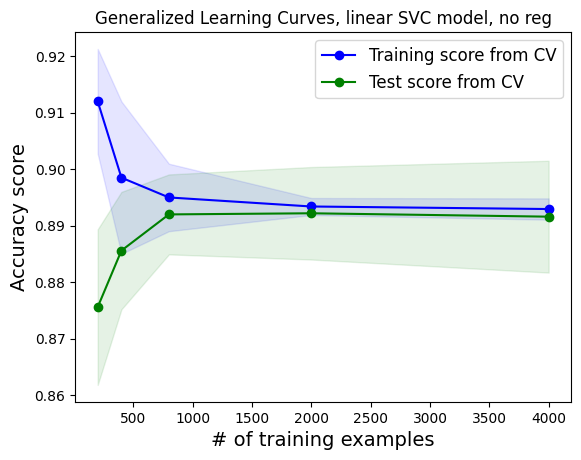

In [465]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg', features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = KFold(n_splits=5, shuffle=True));

### Conclusions

Our classifier is behaving better than a random/lazy one.

Our model does not suffer from high variance, so for improvement we'd look at "high bias" fixes.

Having more data would not help.

### Parameter optimization 

When we optimize parameters with a grid search, we choose the parameters that give the best test scores. This is different from what would happen with new data - to do this fairly, at no point of the training procedure we are allowed to look at the test labels. Therefore, we would need to do <b> nested cross validation </b> to avoid leakage between the parameter optimization and the cross validation procedure and properly evaluate the generalization error.

In [466]:
piped_model = make_pipeline(StandardScaler(), SVC()) #now using the general SVC so I can change the kernel

piped_model.get_params() #this shows how we can access parameters both for the scaler and the classifier

{'memory': None,
 'steps': [('standardscaler', StandardScaler()), ('svc', SVC())],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'svc': SVC(),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': None,
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': None,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

### We can define a dictionary of parameter values to run the optimization. 

Note that this might take a while (~5 mins on my laptop, but it was 15' on my previous laptop); the early estimates output by this cell may be misleading because more complex models (in particular high gamma) take longer.

Once you run this cell, the "model" object will have attributes "best_score_", "best_params_" and "best_estimator_", which give us access to the optimal estimator (printed out), as well as "cv_results_" that can be used to visualize the performance of all models.

In [467]:
#optimizing SVC: THIS IS NOT YET NESTED CV

#parameters = {'svc__kernel': ['poly'], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], 'svc__degree': [2, 4, 8]}

parameters = {'svc__kernel': ['rbf'], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], 'svc__gamma':[0.00001,'scale', 0.01, 0.1]}

#parameters = {'svc__kernel':['poly', 'rbf'], \
#              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000], \
#              'svc__degree': [2, 4, 8]}

model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)

model.fit(features_lim,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), model.best_params_)
# Best params, best score: 0.8760 {'svc__C': 1.0, 'svc__degree': 4, 'svc__kernel': 'poly'}
# Best params, best score: 0.8962 {'svc__C': 1.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params, best score: 0.8956 {'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


#### Next, we visualize the models in a data frame, and rank them according to their test scores.

I like to look at the mean and std of the test scores, the mean of the train scores (so I can evaluate if they differ and the significance of the result), and also fitting time (we may pick a faster model instead of the best model if the scores are comparable)!

In [468]:
scores_lim = pd.DataFrame(model.cv_results_)

scores_lim.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_svc__C', 'param_svc__gamma', 'param_svc__kernel', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score', 'split0_train_score',
       'split1_train_score', 'split2_train_score', 'split3_train_score',
       'split4_train_score', 'mean_train_score', 'std_train_score'],
      dtype='object')

In [469]:
scores_lim[['params','mean_test_score','std_test_score','mean_train_score', \
            'mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
10,"{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8956,0.008709,0.90435,0.086381
14,"{'svc__C': 100.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8942,0.005192,0.90990,0.122942
5,"{'svc__C': 1.0, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8942,0.008010,0.91260,0.083227
7,"{'svc__C': 1.0, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8942,0.008010,0.91260,0.079150
6,"{'svc__C': 1.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8938,0.007111,0.89745,0.075024
18,"{'svc__C': 1000, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8928,0.008183,0.91945,0.507912
16,"{'svc__C': 1000, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8908,0.003311,0.89390,0.074721
1,"{'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8852,0.005706,0.89380,0.085721
3,"{'svc__C': 0.1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8852,0.005706,0.89380,0.082240
2,"{'svc__C': 0.1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8850,0.005933,0.88570,0.081714


To build some intuition around the results, I find it helpful to ask: what hyperparameter values are common to all the best-performing models? Here, for example, the rbf kernel seems to be constantly preferred, while the values of C and gamma seem to only affect the scores only mildly. Note also that the Grid Search is insensitive to moot parameters combinations; for example, here the first three models are identical, because the degree of the polynomial kernel does not matter when using an rbf kernel. This is less than ideal, of course.

#### We can also isolate one type of kernel to look at it more closely.

In [470]:
#scores_lim[scores_lim['param_svc__kernel'] == 'poly'][['params','mean_test_score','std_test_score',\
#                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

scores_lim[scores_lim['param_svc__kernel'] == 'rbf'][['params','mean_test_score','std_test_score',\
                        'mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', ascending = False)

,params,mean_test_score,std_test_score,mean_train_score,mean_fit_time
10,"{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8956,0.008709,0.90435,0.086381
14,"{'svc__C': 100.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8942,0.005192,0.90990,0.122942
5,"{'svc__C': 1.0, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8942,0.008010,0.91260,0.083227
7,"{'svc__C': 1.0, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8942,0.008010,0.91260,0.079150
6,"{'svc__C': 1.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8938,0.007111,0.89745,0.075024
18,"{'svc__C': 1000, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8928,0.008183,0.91945,0.507912
16,"{'svc__C': 1000, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.8908,0.003311,0.89390,0.074721
1,"{'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.8852,0.005706,0.89380,0.085721
3,"{'svc__C': 0.1, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.8852,0.005706,0.89380,0.082240
2,"{'svc__C': 0.1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.8850,0.005933,0.88570,0.081714


### Final diagnosis 

The problem here is high bias, which is not that surprising given that we are using only a subset of features.

We can try two things: making up new features which might help, based on what we know about the problem, and using an imputing strategy to include information about the discarded features.

### Next step: define some new variables. 

In [471]:
features = features.fillna(0) #takes care of nan

In [472]:
features = features.replace('', 0) #takes care of empty string values

In [473]:
features.head()

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.19933,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
1,57594.2,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.65386,-3.129630,0,0.0,0.0,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
2,82313.3,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.68461,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
3,30610.8,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.87132,0.817631,j,28235.4,25887.9,-0.411528,2.024290,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
4,45153.1,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.87641,0.865381,j,746585.0,26219.3,4.041820,-0.874169,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


#### Let's start by looking at what kind of particles we have as a product of the collision.

In [474]:
np.unique(np.array([features['Type_'+str(i)].values for i in range(1,14)]).astype('str'))

array(['0', 'b', 'e+', 'e-', 'g', 'j', 'm+', 'm-'], dtype='<U2')

#### Here are the proposed new features (justification can be found in Chapter 4).
    
    1. The total number of particles produced
    2. The total number of b jets
    3. The total number of jets
    4. The total number of leptons (electrons, positron, mu+, mu-)

In [475]:
#count number of non-zero types 

ntot = np.array([-(np.sum(np.array([features['Type_'+str(i)].values[j] == 0 for i in range(1,14)])) - 13) for j in range(features.shape[0])])

In [476]:
#define new column in my data frame

features['Total_products'] = ntot

In [477]:
#count number of b jets 

nbtot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'b' for i in range(1,14)])) for j in range(features.shape[0])])

In [478]:
#define new column in my data frame

features['Total_b'] = nbtot

In [479]:
#Actually, let's count all types (jets, photons g, e-, e+, mu-, mu+)

njtot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'j' for i in range(1,14)])) for j in range(features.shape[0])])

In [480]:
ngtot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'g' for i in range(1,14)])) for j in range(features.shape[0])])

In [481]:
n_el_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'e-' for i in range(1,14)])) for j in range(features.shape[0])])

In [482]:
n_pos_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'e+' for i in range(1,14)])) for j in range(features.shape[0])])

In [483]:
n_muneg_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'm-' for i in range(1,14)])) for j in range(features.shape[0])])

In [484]:
n_mupos_tot = np.array([np.sum(np.array([features['Type_'+str(i)].values[j] == 'm+' for i in range(1,14)])) for j in range(features.shape[0])])

In [485]:
n_lepton_tot = n_el_tot + n_pos_tot + n_muneg_tot + n_mupos_tot

And here we define the other new features:

In [486]:
features['Total_j'] = njtot
features['Total_g'] = ngtot
features['Total_leptons'] = n_lepton_tot

In [487]:
features.head()

,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,P6,P7,P8,Type_3,P9,P10,P11,P12,Type_4,P13,P14,P15,P16,Type_5,P17,P18,P19,P20,Type_6,P21,P22,P23,P24,Type_7,P25,P26,P27,P28,Type_8,P29,P30,P31,P32,Type_9,P33,P34,P35,P36,Type_10,P37,P38,P39,P40,Type_11,P41,P42,P43,P44,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52,Total_products,Total_b,Total_j,Total_g,Total_leptons
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.19933,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,5,1,3,0,1
1,57594.2,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.65386,-3.129630,0,0.0,0.0,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,4,0,2,0,2
2,82313.3,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.68461,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,5,1,4,0,0
3,30610.8,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.87132,0.817631,j,28235.4,25887.9,-0.411528,2.024290,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,5,1,4,0,0
4,45153.1,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.87641,0.865381,j,746585.0,26219.3,4.041820,-0.874169,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,5,0,5,0,0


### Feature engineering 1: impact of ad-hoc variables

In [488]:
features_lim_2 = features[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16','Total_products', 'Total_b' ,'Total_j','Total_g', 
              'Total_leptons']]

In [489]:
bmodel #remember our benchmark model?

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rando

In [490]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False))

In [491]:
benchmark_lim2_piped = cross_validate(piped_model, features_lim_2, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [492]:
benchmark_lim2_piped

{'fit_time': array([0.00581098, 0.00521517, 0.0057559 , 0.00565577, 0.00588775]),
 'score_time': array([0.0015614 , 0.0010283 , 0.00127959, 0.00098252, 0.00103021]),
 'test_score': array([0.952, 0.939, 0.961, 0.948, 0.94 ]),
 'train_score': array([0.95   , 0.9555 , 0.94825, 0.95   , 0.95   ])}

In [493]:
np.round(benchmark_lim2_piped['test_score'].mean(),3), np.round(benchmark_lim2_piped['test_score'].std(), 3)

(np.float64(0.948), np.float64(0.008))

### This is a very significant improvement, which cuts our error rate in half!

In my experience, this knowledge-informed feature engineering is often very successful, more than hyperparameter optimization. Machine learning methods are often tooted for their ability to learn relevant representations, but non-deep-learning methods are less capable to do so, and providing informative features is very helpful.

In [494]:
piped_model = make_pipeline(StandardScaler(), SVC())

We can optimize this model as well; it will take a while, just like the previous time.

In [495]:
#optimizing SVC: Takes a while!

#parameters = {'svc__kernel':['poly'], 'svc__C':[0.1, 1.0, 10.0, 100.0], 'svc__degree': [2, 4, 8]}
parameters = {'svc__kernel':['rbf'], 'svc__C':[0.1, 1.0, 10.0, 100.0], 'svc__gamma':[0.00001,'scale', 0.01, 0.1]}

#parameters = {'svc__kernel':['poly', 'rbf'], \
#              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0], 'svc__degree': [2, 4, 8]}

nmodels = np.prod([len(el) for el in parameters.values()]) # was np.product
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim_2,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), model.best_params_)
# Best params, best score: 0.9232 {'svc__C': 10.0, 'svc__degree': 4, 'svc__kernel': 'poly'}
# Best params, best score: 0.9458 {'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params, best score: 0.9464 {'svc__C': 1.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


In [496]:
scores_lim_2 = pd.DataFrame(model.cv_results_)
scores_lim_2[['params','mean_test_score','mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', \
                                                    ascending = False)

,params,mean_test_score,mean_train_score,mean_fit_time
6,"{'svc__C': 1.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9464,0.95365,0.061960
10,"{'svc__C': 10.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9460,0.96295,0.069889
12,"{'svc__C': 100.0, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.9446,0.94475,0.074774
5,"{'svc__C': 1.0, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.9436,0.96520,0.077963
2,"{'svc__C': 0.1, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9404,0.94285,0.089591
9,"{'svc__C': 10.0, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.9366,0.98995,0.102205
7,"{'svc__C': 1.0, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.9366,0.98145,0.123201
14,"{'svc__C': 100.0, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9364,0.97755,0.136618
1,"{'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.9334,0.94075,0.093876
11,"{'svc__C': 10.0, 'svc__gamma': 0.1, 'svc__kernel': 'rbf'}",0.9302,0.99990,0.141220


### Another feature engineering attempt we could potentially do is use the type of product in the i-th location as a feature.

We could do it with label encoding, as we did earlier in this notebook, but such strategy introduces a notion of distance metric (labels that are mapped to 0 and 1 are interpreted to be closer to each other than labels that are mapped into 0 and 7). 

As an alternative, we can introduce as many new columns as possible values for each categorical variable we are re-mapping, and we just use a 0/1 to indicate that the particle is of that type. This is achieved with the wonderfully-named "get_dummies" function:

In [497]:
features_add = pd.get_dummies(data=features, columns=['Type_'+str(i) for i in range(1,14)])

In [498]:
features_add.columns[58:80] #A subset of the new features

Index(['Total_leptons', 'Type_1_b', 'Type_1_j', 'Type_2_0', 'Type_2_b',
       'Type_2_e+', 'Type_2_e-', 'Type_2_g', 'Type_2_j', 'Type_2_m+',
       'Type_2_m-', 'Type_3_0', 'Type_3_b', 'Type_3_e+', 'Type_3_e-',
       'Type_3_g', 'Type_3_j', 'Type_3_m+', 'Type_3_m-', 'Type_4_0',
       'Type_4_b', 'Type_4_e+'],
      dtype='object')

In [499]:
features_add.shape

(5000, 156)

### Feature engineering 2: add other variables (type of product) for the first four particles.

In [539]:
features_lim_3 = features_add[['MET', 'METphi', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11',
       'P12',  'P13', 'P14', 'P15', 'P16','Total_products', 'Total_b' ,'Total_j','Total_g', 
              'Total_leptons','Type_1_b',
       'Type_1_j', 'Type_2_0', 'Type_2_b', 'Type_2_e+', 'Type_2_e-',
       'Type_2_g', 'Type_2_j', 'Type_2_m+', 'Type_2_m-', 'Type_3_0',
       'Type_3_b', 'Type_3_e+', 'Type_3_e-', 'Type_3_g', 'Type_3_j',
       'Type_3_m+', 'Type_3_m-', 'Type_4_0', 'Type_4_b', 'Type_4_e+',
       'Type_4_e-', 'Type_4_g', 'Type_4_j', 'Type_4_m+', 'Type_4_m-']]

In [540]:
features_lim_3 = features_lim_3.drop(['P3','P4','P5','P12'], axis=1) #This is a circular variable, so it is not useful for our purposes. We will drop it.


In [541]:
features_lim_3.head()

,MET,METphi,P1,P2,P6,P7,P8,P9,P10,P11,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons,Type_1_b,Type_1_j,Type_2_0,Type_2_b,Type_2_e+,Type_2_e-,Type_2_g,Type_2_j,Type_2_m+,Type_2_m-,Type_3_0,Type_3_b,Type_3_e+,Type_3_e-,Type_3_g,Type_3_j,Type_3_m+,Type_3_m-,Type_4_0,Type_4_b,Type_4_e+,Type_4_e-,Type_4_g,Type_4_j,Type_4_m+,Type_4_m-
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,140289.0,76955.8,-1.19933,-1.302800,5,1,3,0,1,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,57594.2,-0.509253,161529.0,80458.3,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,72883.9,26902.2,-1.65386,-3.129630,4,0,2,0,2,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False
2,82313.3,1.686840,167130.0,113078.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,77714.0,27801.5,1.68461,1.389690,5,1,4,0,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
3,30610.8,2.617120,112267.0,61383.9,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,90096.7,26964.5,1.87132,0.817631,5,1,4,0,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,45153.1,-2.241350,178174.0,100164.0,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,104193.0,31151.0,1.87641,0.865381,5,0,5,0,0,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False


In [542]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False))

In [543]:
benchmark = cross_validate(piped_model, features_lim_3, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [544]:
benchmark

{'fit_time': array([0.03529978, 0.02181721, 0.01931214, 0.02283835, 0.0258708 ]),
 'score_time': array([0.00300264, 0.00196505, 0.00166893, 0.00167489, 0.00163841]),
 'test_score': array([0.956, 0.936, 0.961, 0.949, 0.939]),
 'train_score': array([0.94925, 0.95225, 0.9475 , 0.9505 , 0.9505 ])}

In [545]:
np.round(benchmark['test_score'].mean(),3), np.round(benchmark['test_score'].std(), 3)

(np.float64(0.948), np.float64(0.01))

In [546]:
np.round(benchmark['train_score'].mean(),3), np.round(benchmark['train_score'].std(), 3)

(np.float64(0.95), np.float64(0.002))

#### No further improvement is observed, although we should optimize the model.

In [547]:
piped_model = make_pipeline(StandardScaler(), SVC())

In [548]:
#optimizing SVC: 

parameters = {'svc__kernel':['poly', 'rbf'], \
              'svc__gamma':[0.00001,'scale', 0.01, 0.1], 'svc__C':[0.1, 1.0, 10.0, 100.0, 1000.0], 'svc__degree': [4]} #poly never helps
nmodels = np.prod([len(el) for el in parameters.values()])
model = GridSearchCV(piped_model, parameters, cv = StratifiedKFold(n_splits=5, shuffle=True), \
                     verbose = 2, n_jobs = 4, return_train_score=True)
model.fit(features_lim_3,target)

print('Best params, best score:', "{:.4f}".format(model.best_score_), \
      model.best_params_)

scores_lim_3 = pd.DataFrame(model.cv_results_)
scores_lim_3[['params','mean_test_score','mean_train_score','mean_fit_time']].sort_values(by = 'mean_test_score', \
                                                    ascending = False)
# Best params, best score: 0.9466 {'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best params, best score: 0.9478 {'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


,params,mean_test_score,mean_train_score,mean_fit_time
11,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.9478,0.95940,0.100563
33,"{'svc__C': 1000.0, 'svc__degree': 4, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.9476,0.95000,0.083268
13,"{'svc__C': 1.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9474,0.95510,0.089697
21,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9456,0.96405,0.092589
25,"{'svc__C': 100.0, 'svc__degree': 4, 'svc__gamma': 1e-05, 'svc__kernel': 'rbf'}",0.9438,0.94470,0.100303
19,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.9424,0.97950,0.115353
5,"{'svc__C': 0.1, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9392,0.94220,0.121351
3,"{'svc__C': 0.1, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}",0.9374,0.94130,0.123797
29,"{'svc__C': 100.0, 'svc__degree': 4, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}",0.9374,0.98125,0.157698
18,"{'svc__C': 10.0, 'svc__degree': 4, 'svc__gamma': 'scale', 'svc__kernel': 'poly'}",0.9328,0.97275,0.132209


### Finally, we can try with all the features.

In [549]:
features_add.shape

(5000, 156)

In [550]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000))

In [551]:
cv

StratifiedKFold(n_splits=5, random_state=101, shuffle=True)

In [552]:
benchmark = cross_validate(piped_model, features_add, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [553]:
benchmark

{'fit_time': array([0.41891479, 1.05191469, 0.75770497, 0.11608911, 0.07710147]),
 'score_time': array([0.00394034, 0.0039022 , 0.00389552, 0.00558186, 0.00392413]),
 'test_score': array([0.94 , 0.93 , 0.956, 0.929, 0.929]),
 'train_score': array([0.95275, 0.957  , 0.949  , 0.95675, 0.956  ])}

In [554]:
np.round(benchmark['test_score'].mean(),3), np.round(benchmark['test_score'].std(), 3)

(np.float64(0.937), np.float64(0.01))

In [555]:
np.round(benchmark['train_score'].mean(),3), np.round(benchmark['train_score'].std(), 3)

(np.float64(0.954), np.float64(0.003))

#### An interesting (but perhaps not surprising) observation is that the model with all features has higher variance.

We could run the optimization, but as you might have anticipated, it won't help much, and it is very time consuming.

### Take-home message: feature engineering often works best if we use subject matter knowledge, and buulding more features is not necessarily better.

In [556]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False, C = 1000)) #changed to linear SVC
# why C = 1000 ?
benchmark_lim_piped = cross_validate(piped_model, features_lim_3, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [557]:
print('train accuracy = %.3f +/- %.3f' % (benchmark_lim_piped['train_score'].mean(),benchmark_lim_piped['train_score'].std()))

train accuracy = 0.950 +/- 0.002


## Conclusion:

I dropped couple columns, could not pass 95% Accuracy!

List if what I dropped: (I tried with different dropped but accuracy got worse!)

In [558]:
#features_lim_3 = features_lim_3.drop(['P3','P4','P5','P12'], axis=1) #This is a circular variable, so it is not useful for our purposes. We will drop it.